In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(42)
NUM_APPLICANTS = 10000

print("Initializing Federal Bank Simulator: Generating Synthetic Mortgage Data...")

print("1/3 Generating Applicant Profiles...")
applicant_ids = [f"APP-{str(i).zfill(6)}" for i in range(1, NUM_APPLICANTS + 1)]
employment_types = np.random.choice(['Salaried', 'Self-Employed'], NUM_APPLICANTS, p=[0.65, 0.35])
tier_cities = np.random.choice(['Tier 1', 'Tier 2', 'Tier 3'], NUM_APPLICANTS, p=[0.3, 0.5, 0.2])

# Generate CIBIL Scores (Self-employed generally have slightly wider variance)
cibil_scores = np.where(
    employment_types == 'Salaried',
    np.random.normal(740, 40, NUM_APPLICANTS),
    np.random.normal(710, 60, NUM_APPLICANTS)
)
cibil_scores = np.clip(cibil_scores, 300, 900).astype(int) # Ensure valid CIBIL range

# Monthly income (Skewed higher for Tier 1, varied by employment)
monthly_income = np.where(
    tier_cities == 'Tier 1',
    np.random.lognormal(mean=11.5, sigma=0.5, size=NUM_APPLICANTS), # ~100k median
    np.random.lognormal(mean=11.0, sigma=0.5, size=NUM_APPLICANTS)  # ~60k median
).astype(int)

# Existing monthly obligations (for DTI calculation later)
obligations = (monthly_income * np.random.uniform(0.1, 0.4, NUM_APPLICANTS)).astype(int)

applicants_df = pd.DataFrame({
    'applicant_id': applicant_ids,
    'age': np.random.randint(25, 55, NUM_APPLICANTS),
    'employment_type': employment_types,
    'tier_city': tier_cities,
    'cibil_score': cibil_scores,
    'monthly_income': monthly_income,
    'existing_obligations': obligations
})

print("2/3 Structuring Loan Facilities & LTVs...")
loan_ids = [f"LN-{str(i).zfill(6)}" for i in range(1, NUM_APPLICANTS + 1)]

# Sanction amounts based on income and city
sanction_amounts = (monthly_income * np.random.uniform(40, 70, NUM_APPLICANTS)).astype(int)
sanction_amounts = np.round(sanction_amounts, -5) # Round to nearest lakh

# LTV Ratios (Riskier profiles get pushed closer to 85-90% regulatory limits)
ltv_ratios = np.random.uniform(0.60, 0.90, NUM_APPLICANTS)
ltv_ratios = np.where(cibil_scores < 650, np.clip(ltv_ratios + 0.1, 0, 0.9), ltv_ratios)

# Interest rates (Base rate + risk premium based on CIBIL)
base_rate = 8.5
interest_rates = base_rate + np.where(cibil_scores > 750, 0,
                             np.where(cibil_scores > 650, 0.75, 1.5))

loan_terms_df = pd.DataFrame({
    'loan_id': loan_ids,
    'applicant_id': applicant_ids, # Foreign Key to applicants
    'sanction_amount': sanction_amounts,
    'ltv_ratio': np.round(ltv_ratios, 2),
    'interest_rate': interest_rates,
    'tenure_months': np.random.choice([120, 180, 240, 360], NUM_APPLICANTS, p=[0.1, 0.3, 0.5, 0.1]),
    'branch_code': np.random.choice(['BR-001', 'BR-002', 'BR-003', 'BR-004', 'BR-005'], NUM_APPLICANTS)
})

print("3/3 Simulating 12 Months of Repayment History (Embedding NPA indicators)...")
history_records = []

# Base dates for the simulation (last 12 months)
start_date = datetime(2023, 6, 1)

for index, row in loan_terms_df.iterrows():
    app_info = applicants_df[applicants_df['applicant_id'] == row['applicant_id']].iloc[0]

    # EMBEDDED DOMAIN LOGIC: Define risk of bounce based on profile
    # If Self-Employed in Tier 2/3 with low CIBIL and high LTV, bounce risk is significantly higher
    base_bounce_prob = 0.02
    if app_info['employment_type'] == 'Self-Employed' and app_info['tier_city'] in ['Tier 2', 'Tier 3']:
        base_bounce_prob += 0.04
    if app_info['cibil_score'] < 680:
        base_bounce_prob += 0.05
    if row['ltv_ratio'] > 0.85:
        base_bounce_prob += 0.03

    avg_bank_balance = app_info['monthly_income'] * np.random.uniform(1.2, 3.0)

    for month in range(12):
        due_date = start_date + timedelta(days=30*month)

        # Determine if this EMI bounces
        is_bounce = 1 if random.random() < base_bounce_prob else 0

        # Simulate dropping bank balances for accounts that bounce
        if is_bounce:
            avg_bank_balance = avg_bank_balance * 0.7 # Balance drops indicating stress

        history_records.append({
            'payment_id': f"PAY-{row['loan_id']}-{month+1}",
            'loan_id': row['loan_id'], # Foreign Key to loans
            'month_year': due_date.strftime('%Y-%m'),
            'emi_due_date': due_date.strftime('%Y-%m-05'), # EMI due on 5th
            'bounce_flag': is_bounce,
            'avg_bank_balance_that_month': int(avg_bank_balance)
        })

repayment_history_df = pd.DataFrame(history_records)

print("\nExporting datasets to CSV...")
applicants_df.to_csv('applicants_table.csv', index=False)
loan_terms_df.to_csv('loan_terms_table.csv', index=False)
repayment_history_df.to_csv('repayment_history_table.csv', index=False)

Initializing Federal Bank Simulator: Generating Synthetic Mortgage Data...
1/3 Generating Applicant Profiles...
2/3 Structuring Loan Facilities & LTVs...
3/3 Simulating 12 Months of Repayment History (Embedding NPA indicators)...

Exporting datasets to CSV...


# New Section

In [4]:
import sqlite3
import pandas as pd

# 1. Read the CSV files (Updated to find them in your root directory)
print("Loading CSV files into memory...")
try:
    # Looks in the root directory where you uploaded them
    applicants_df = pd.read_csv('/applicants_table.csv')
    loan_terms_df = pd.read_csv('/loan_terms_table.csv')
    repayment_history_df = pd.read_csv('/repayment_history_table.csv')
except FileNotFoundError:
    # Fallback just in case they are in the default folder
    applicants_df = pd.read_csv('applicants_table.csv')
    loan_terms_df = pd.read_csv('loan_terms_table.csv')
    repayment_history_df = pd.read_csv('repayment_history_table.csv')

# 2. Create a virtual, in-memory SQL database
conn = sqlite3.connect(':memory:')

# 3. Push our three datasets into this SQL database
applicants_df.to_sql('applicants', conn, index=False)
loan_terms_df.to_sql('loan_terms', conn, index=False)
repayment_history_df.to_sql('repayment_history', conn, index=False)

print("SQL Database Ready! Executing Executive Risk Query...\n")

# 4. THE ARCHITECT's SQL QUERY
executive_query = """
    WITH Bouncing_Accounts AS (
        -- Step A: Find out how many times each loan bounced
        SELECT
            loan_id,
            SUM(bounce_flag) as total_bounces
        FROM repayment_history
        GROUP BY loan_id
    )
    -- Step B: Join everything together to see the big picture
    SELECT
        a.employment_type,
        a.tier_city,
        COUNT(a.applicant_id) as total_loans,
        SUM(CASE WHEN b.total_bounces >= 3 THEN 1 ELSE 0 END) as npa_high_risk_loans,
        -- Calculate NPA % and round it
        ROUND(CAST(SUM(CASE WHEN b.total_bounces >= 3 THEN 1 ELSE 0 END) AS FLOAT) / COUNT(a.applicant_id) * 100, 2) as npa_risk_percentage

    FROM applicants a
    JOIN loan_terms l ON a.applicant_id = l.applicant_id
    JOIN Bouncing_Accounts b ON l.loan_id = b.loan_id

    GROUP BY a.employment_type, a.tier_city
    ORDER BY npa_risk_percentage DESC;
"""

# 5. Run the SQL query and display the results
risk_report = pd.read_sql_query(executive_query, conn)
print(risk_report.to_string(index=False))

Loading CSV files into memory...
SQL Database Ready! Executing Executive Risk Query...

employment_type tier_city  total_loans  npa_high_risk_loans  npa_risk_percentage
  Self-Employed    Tier 3          687                   57                 8.30
  Self-Employed    Tier 2         1709                  136                 7.96
  Self-Employed    Tier 1         1001                   23                 2.30
       Salaried    Tier 3         1346                   12                 0.89
       Salaried    Tier 1         1932                   14                 0.72
       Salaried    Tier 2         3325                   18                 0.54


/tmp/ipykernel_3696/3469018706.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


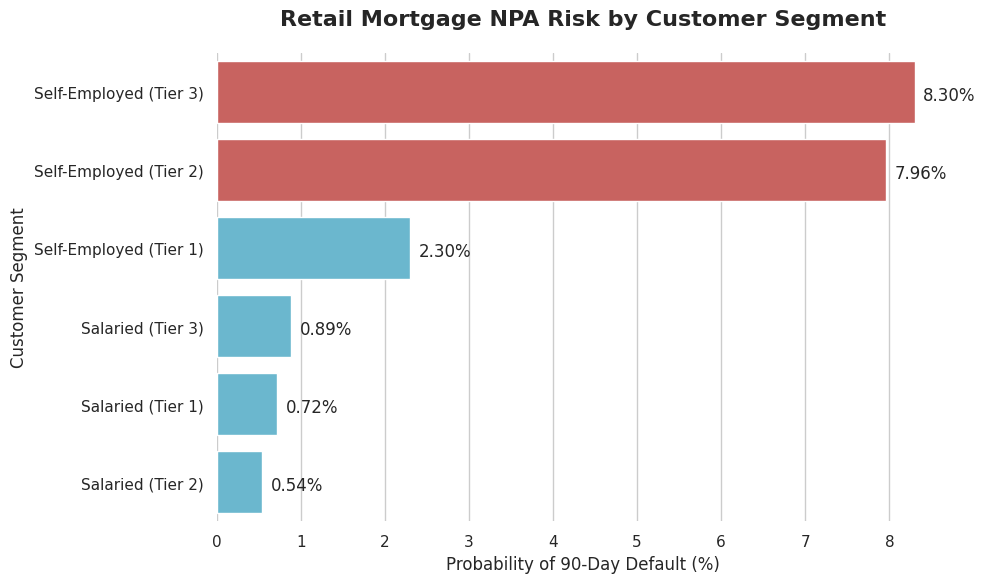

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional, banking-style aesthetic
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create a combined label for the chart
risk_report['Segment'] = risk_report['employment_type'] + " (" + risk_report['tier_city'] + ")"

# Create a bar chart highlighting the high-risk segments in RED and low-risk in BLUE
colors = ['#d9534f' if risk > 5 else '#5bc0de' for risk in risk_report['npa_risk_percentage']]

ax = sns.barplot(
    data=risk_report,
    y='Segment',
    x='npa_risk_percentage',
    palette=colors
)

# Add titles and labels for executives
plt.title('Retail Mortgage NPA Risk by Customer Segment', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Probability of 90-Day Default (%)', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)

# Add the exact percentages to the bars
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.1, p.get_y() + p.get_height()/2. + 0.1, '{:1.2f}%'.format(width), ha="left")

# Clean up borders
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()